## Install Dependencies

In [1]:
#  CELL 1 — Install Dependencies                                          ║


import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pydicom", "albumentations"], check=True)

print(" Packages installed.")



✅ Packages installed.


## Import Libraries

In [7]:
#  CELL 2 — Import Libraries                                              


import os, cv2, random, json, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
import pydicom
import albumentations as A

import tensorflow as tf

# Use Keras 3 directly — do NOT import tf_keras
import keras
from keras import layers, ops
from keras import backend as K
from keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau,
    TensorBoard, CSVLogger
)

warnings.filterwarnings("ignore")

print("=" * 50)
print(f"  TensorFlow : {tf.__version__}")
print(f"  Keras      : {keras.__version__}")
print(f"  GPU        : {tf.config.list_physical_devices('GPU')}")
print("=" * 50)

  TensorFlow : 2.19.0
  Keras      : 3.10.0
  GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Global Configuration

In [9]:
#   CELL 3 — Global Configuration                                          

CFG = {
    # ── Paths 
    "DATA_ROOT"   : "/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset",
    "WORK_DIR"    : "/kaggle/working",
    "CKPT_DIR"    : "/kaggle/working/checkpoints",

    # Checkpoint file names
    "BEST_CKPT"   : "/kaggle/working/checkpoints/best_model.keras",       # best val dice
    "LAST_CKPT"   : "/kaggle/working/checkpoints/last_epoch_model.keras", # resume target
    "EPOCH_LOG"   : "/kaggle/working/checkpoints/epoch_log.json",         # tracks last epoch

    # ── Image 
    "IMG_SIZE"    : 256,
    "CHANNELS"    : 3,      # repeat grayscale → 3ch for pretrained encoder

    # ── Training 
    "BATCH_SIZE"  : 8,
    "EPOCHS"      : 100,
    "LR"          : 3e-4,
    "PATIENCE"    : 12,     # EarlyStopping patience
    "VAL_SPLIT"   : 0.15,
    "TEST_SPLIT"  : 0.10,
    "SEED"        : 42,

    # ── Model 
    "BACKBONE"    : "resnet34",
}

# Create directories
os.makedirs(CFG["CKPT_DIR"], exist_ok=True)
os.makedirs(f"{CFG['WORK_DIR']}/outputs", exist_ok=True)

# Fix all random seeds for reproducibility
random.seed(CFG["SEED"])
np.random.seed(CFG["SEED"])
tf.random.set_seed(CFG["SEED"])

print(f" Config loaded. Working dir  : {CFG['WORK_DIR']}")
print(f" Checkpoint dir              : {CFG['CKPT_DIR']}")

 Config loaded. Working dir  : /kaggle/working
 Checkpoint dir              : /kaggle/working/checkpoints


Verifying fixed mask extraction on 5 samples:
--------------------------------------------------
  ✅ 10002.png  →   1266 lesion px  (0.48%)
  ✅ 10033.png  →   6864 lesion px  (2.62%)
  ✅ 10036.png  →   1688 lesion px  (0.64%)
  ✅ 10039.png  →   1101 lesion px  (0.42%)
  ✅ 10045.png  →    740 lesion px  (0.28%)
--------------------------------------------------
   All masks OK!


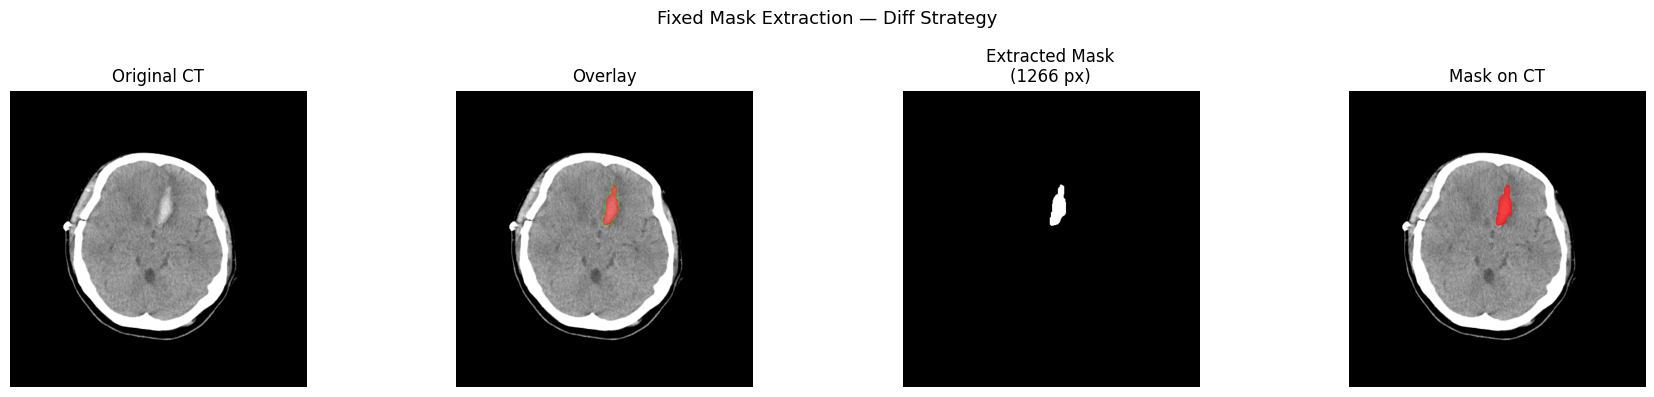

In [10]:
# ── FINAL FIX: overlay_to_binary_mask 
import cv2
import numpy as np
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset")

def overlay_to_binary_mask(overlay_bgr: np.ndarray,
                           orig_bgr: np.ndarray) -> np.ndarray:
    """
    Overlay image is almost identical to original CT (grayscale).
    Lesion is marked by subtle brightness/contrast change — NOT color.
    
    Strategy: pixel-wise absolute difference between overlay and original.
    Pixels that changed significantly = lesion region.
    
    Threshold=15 catches subtle changes; morphological cleanup removes noise.
    """
    # Absolute difference — where did the overlay change the CT?
    diff      = cv2.absdiff(overlay_bgr, orig_bgr)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    
    # Threshold: any pixel that changed by more than 15 intensity units
    _, mask = cv2.threshold(diff_gray, 15, 255, cv2.THRESH_BINARY)
    
    # Remove tiny noise with morphological opening (3×3 kernel)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    
    # Fill small holes inside lesion with closing
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    return mask


# ── Verify on 5 samples 
print("Verifying fixed mask extraction on 5 samples:")
print("-" * 50)

bleed_overlays = sorted((DATA_ROOT / "Bleeding" / "OVERLAY").glob("*.png"))[:5]
all_ok = True

for ov_path in bleed_overlays:
    orig_path = DATA_ROOT / "Bleeding" / "PNG" / ov_path.name
    ov_bgr    = cv2.imread(str(ov_path),   cv2.IMREAD_COLOR)
    orig_bgr  = cv2.imread(str(orig_path), cv2.IMREAD_COLOR)
    
    mask      = overlay_to_binary_mask(ov_bgr, orig_bgr)
    px_count  = np.sum(mask > 0)
    ratio     = 100 * px_count / mask.size
    status    = "✅" if px_count > 100 else "❌"
    
    if px_count <= 100:
        all_ok = False
    
    print(f"  {status} {ov_path.name}  →  {px_count:5d} lesion px  ({ratio:.2f}%)")

print("-" * 50)
print(f"  {' All masks OK!' if all_ok else ' Some masks still empty!'}")


# ── Visual check 
ov_path   = bleed_overlays[0]
orig_path = DATA_ROOT / "Bleeding" / "PNG" / ov_path.name
ov_bgr    = cv2.imread(str(ov_path),   cv2.IMREAD_COLOR)
orig_bgr  = cv2.imread(str(orig_path), cv2.IMREAD_COLOR)
mask      = overlay_to_binary_mask(ov_bgr, orig_bgr)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original CT")

axes[1].imshow(cv2.cvtColor(ov_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("Overlay")

axes[2].imshow(mask, cmap="gray")
axes[2].set_title(f"Extracted Mask\n({np.sum(mask>0)} px)")

# Overlay mask on CT as red tint
vis = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
lesion = mask > 0
vis[lesion, 0] = np.clip(vis[lesion, 0] * 0.3 + 180, 0, 255)
vis[lesion, 1] = vis[lesion, 1] * 0.3
vis[lesion, 2] = vis[lesion, 2] * 0.3
axes[3].imshow(vis.astype(np.uint8))
axes[3].set_title("Mask on CT")

for ax in axes: ax.axis("off")
plt.suptitle("Fixed Mask Extraction — Diff Strategy", fontsize=13)
plt.tight_layout()
plt.show()

##  Dataset Discovery & Image–Mask Pairing

In [11]:
#  CELL 4 — Dataset Discovery & Image–Mask Pairing                     

"""
  Dataset structure:
    Bleeding/     → PNG/ + OVERLAY/   ← overlay is grayscale CT, NOT colored
    Ischemia/     → PNG/ + OVERLAY/   ← same format
    Normal/       → PNG/ only         ← SKIPPED (no masks)
    External_Test → PNG/ + MASKS/     ← real binary PNG masks




"""

DATA_ROOT = Path(CFG["DATA_ROOT"])


def load_png(path: Path, grayscale: bool = False) -> np.ndarray:
    """Load a PNG image using OpenCV. Returns uint8 numpy array."""
    flag = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
    img  = cv2.imread(str(path), flag)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    return img


def overlay_to_binary_mask(overlay_bgr: np.ndarray,
                           orig_bgr: np.ndarray) -> np.ndarray:
    """
    OVERLAY IMAGE IS GRAYSCALE (R≈G≈B) — NOT a colored overlay.
    Lesion region is marked by subtle brightness change only.

    Strategy: absdiff(overlay, original_CT) → threshold → morphological cleanup.
      - threshold=15  : catches subtle brightness changes
      - MORPH_OPEN    : removes small noise pixels
      - MORPH_CLOSE   : fills small holes inside lesion region

    Returns: uint8 mask, values 0 (background) or 255 (lesion).
    """
    # pixel-wise absolute difference between overlay and original CT
    diff      = cv2.absdiff(overlay_bgr, orig_bgr)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    # threshold: pixels that changed by > 15 intensity units = lesion
    _, mask = cv2.threshold(diff_gray, 15, 255, cv2.THRESH_BINARY)

    # morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)  # noise remove
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # hole fill

    return mask


def collect_paired_samples() -> pd.DataFrame:
    """
    Walk all dataset folders and return a DataFrame with columns:
      image      : Path to PNG image
      mask       : Path to mask/overlay PNG
      mask_type  : 'overlay' | 'binary'
      label      : 'bleeding' | 'ischemia' | 'external'

    Images without a corresponding mask are silently skipped.
    Normal/ folder skipped entirely — no masks available.
    """
    records = []

    # ── Bleeding: PNG + OVERLAY 
    bleed_imgs    = sorted((DATA_ROOT / "Bleeding" / "PNG").glob("*.png"))
    bleed_overlay = {p.stem: p for p in
                     sorted((DATA_ROOT / "Bleeding" / "OVERLAY").glob("*.png"))}

    for img_p in bleed_imgs:
        if img_p.stem in bleed_overlay:
            records.append({
                "image"    : img_p,
                "mask"     : bleed_overlay[img_p.stem],
                "mask_type": "overlay",
                "label"    : "bleeding",
            })

    # ── Ischemia: PNG + OVERLAY 
    isch_imgs    = sorted((DATA_ROOT / "Ischemia" / "PNG").glob("*.png"))
    isch_overlay = {p.stem: p for p in
                    sorted((DATA_ROOT / "Ischemia" / "OVERLAY").glob("*.png"))}

    for img_p in isch_imgs:
        if img_p.stem in isch_overlay:
            records.append({
                "image"    : img_p,
                "mask"     : isch_overlay[img_p.stem],
                "mask_type": "overlay",
                "label"    : "ischemia",
            })

    # ── External_Test: PNG + MASKS (real binary masks) 
    ext_imgs  = sorted((DATA_ROOT / "External_Test" / "PNG").glob("*.png"))
    ext_masks = {p.stem: p for p in
                 sorted((DATA_ROOT / "External_Test" / "MASKS").glob("*.png"))}

    for img_p in ext_imgs:
        if img_p.stem in ext_masks:
            records.append({
                "image"    : img_p,
                "mask"     : ext_masks[img_p.stem],
                "mask_type": "binary",
                "label"    : "external",
            })

    # ── Normal: SKIPPED — no masks, no pseudo-masks 

    df = pd.DataFrame(records)
    print(f"Total paired samples  : {len(df)}")
    print(df["label"].value_counts().to_string())
    return df


df_all = collect_paired_samples()

Total paired samples  : 2423
label
ischemia    1130
bleeding    1093
external     200


##  Diagnostic: Mask Verification

STEP 1: Verify mask extraction on 5 raw overlay files
  ✅ 10002.png  ->   1266 lesion px  (0.48%)
  ✅ 10033.png  ->   6864 lesion px  (2.62%)
  ✅ 10036.png  ->   1688 lesion px  (0.64%)
  ✅ 10039.png  ->   1101 lesion px  (0.42%)
  ✅ 10045.png  ->    740 lesion px  (0.28%)

 Raw mask extraction working correctly!

STEP 2: Visual — Original CT | Overlay | Extracted Mask


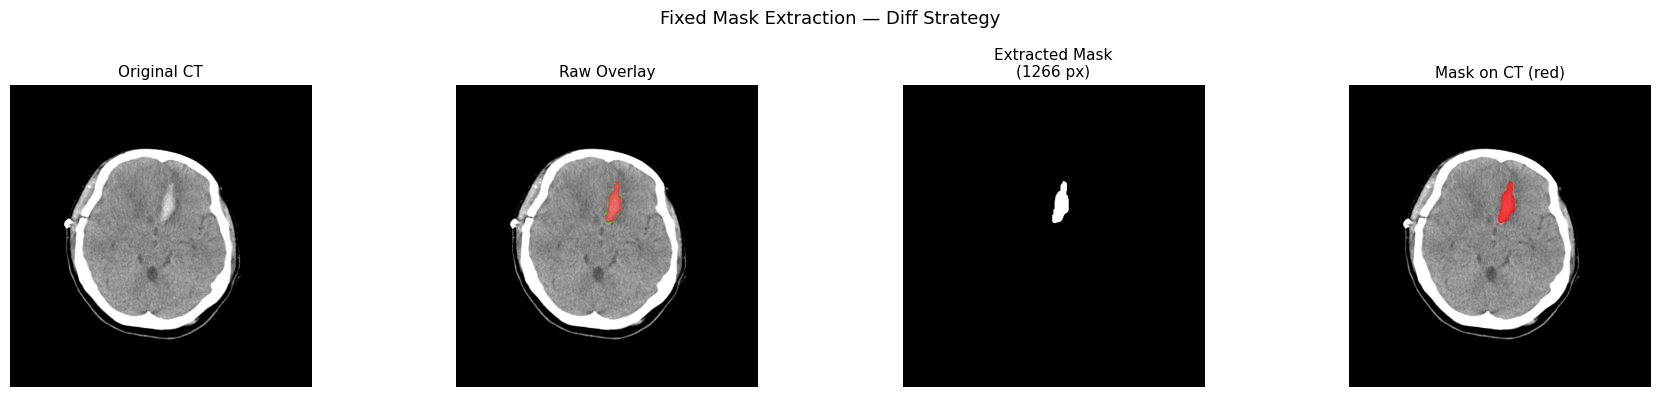

 Figure saved -> /kaggle/working/outputs/mask_verification.png

STEP 3: Generator batch mask check
  Batch size           : 8
  Masks with lesion px : 7 / 8
  Lesion pixel ratio   : 0.987%

   Generator masks OK — ready to start training!


In [19]:
#   CELL 4b — Mask Verification (Run this cell AFTER Cell 8)       

"""
Verify that the fixed overlay_to_binary_mask() is working correctly.
Since overlays are grayscale CT images (R≈G≈B), we use the diff strategy:
absdiff(overlay, original_CT) → threshold → morphological cleanup.


"""

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Raw file check 
print("=" * 55)
print("STEP 1: Verify mask extraction on 5 raw overlay files")
print("=" * 55)

bleed_overlays = sorted((DATA_ROOT / "Bleeding" / "OVERLAY").glob("*.png"))[:5]
all_ok = True

for ov_path in bleed_overlays:
    orig_path = DATA_ROOT / "Bleeding" / "PNG" / ov_path.name
    ov_bgr    = cv2.imread(str(ov_path),   cv2.IMREAD_COLOR)
    orig_bgr  = cv2.imread(str(orig_path), cv2.IMREAD_COLOR)

    if ov_bgr is None or orig_bgr is None:
        print(f"   Cannot read: {ov_path.name}")
        all_ok = False
        continue

    mask     = overlay_to_binary_mask(ov_bgr, orig_bgr)
    px_count = np.sum(mask > 0)
    ratio    = 100 * px_count / mask.size
    status   = "✅" if px_count > 100 else "❌"

    if px_count <= 100:
        all_ok = False

    print(f"  {status} {ov_path.name}  ->  {px_count:5d} lesion px  ({ratio:.2f}%)")

print()
if all_ok:
    print(" Raw mask extraction working correctly!")
else:
    print(" Some masks still empty — consider adjusting the threshold!")


#  Visual check 
print("\n" + "=" * 55)
print("STEP 2: Visual — Original CT | Overlay | Extracted Mask")
print("=" * 55)

ov_path   = bleed_overlays[0]
orig_path = DATA_ROOT / "Bleeding" / "PNG" / ov_path.name
ov_bgr    = cv2.imread(str(ov_path),   cv2.IMREAD_COLOR)
orig_bgr  = cv2.imread(str(orig_path), cv2.IMREAD_COLOR)
mask      = overlay_to_binary_mask(ov_bgr, orig_bgr)

# Build red overlay visualization: highlight lesion region in red on CT
vis           = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
lesion_px     = mask > 0
vis[lesion_px, 0] = np.clip(vis[lesion_px, 0] * 0.3 + 180, 0, 255)  # boost red
vis[lesion_px, 1] = vis[lesion_px, 1] * 0.3                           # suppress green
vis[lesion_px, 2] = vis[lesion_px, 2] * 0.3                           # suppress blue

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
data = [
    (cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB), None,   "Original CT"),
    (cv2.cvtColor(ov_bgr,   cv2.COLOR_BGR2RGB), None,   "Raw Overlay"),
    (mask,                                       "gray", f"Extracted Mask\n({np.sum(mask>0)} px)"),
    (vis.astype(np.uint8),                       None,   "Mask on CT (red)"),
]
for ax, (img, cmap, title) in zip(axes, data):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Fixed Mask Extraction — Diff Strategy", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/outputs/mask_verification.png",
            dpi=120, bbox_inches="tight")
plt.show()
print(" Figure saved -> /kaggle/working/outputs/mask_verification.png")


#  Generator batch check 
# NOTE: This step requires Cell 8 to be run first (train_gen must be defined)
print("\n" + "=" * 55)
print("STEP 3: Generator batch mask check")
print("=" * 55)

try:
    imgs_b, masks_b = train_gen[0]
    nonzero = sum(np.any(m > 0) for m in masks_b)
    ratio   = 100 * np.sum(masks_b) / masks_b.size

    print(f"  Batch size           : {len(imgs_b)}")
    print(f"  Masks with lesion px : {nonzero} / {len(masks_b)}")
    print(f"  Lesion pixel ratio   : {ratio:.3f}%")

    if nonzero == 0:
        print("\n  ❌ ALL MASKS ARE ZERO — check _load_single() in Cell 8!")
    elif nonzero < len(masks_b) // 2:
        print(f"\n  ⚠️  Only {nonzero}/{len(masks_b)} masks have lesion pixels.")
        print("      This may be normal if some slices have no visible lesion.")
    else:
        print(f"\n   Generator masks OK — ready to start training!")

except NameError:
    print("  ⚠️  train_gen is not defined yet.")
    print("      Run Cell 8 first, then re-run this cell.")

##  Visualize Sample Images & Their Real Masks

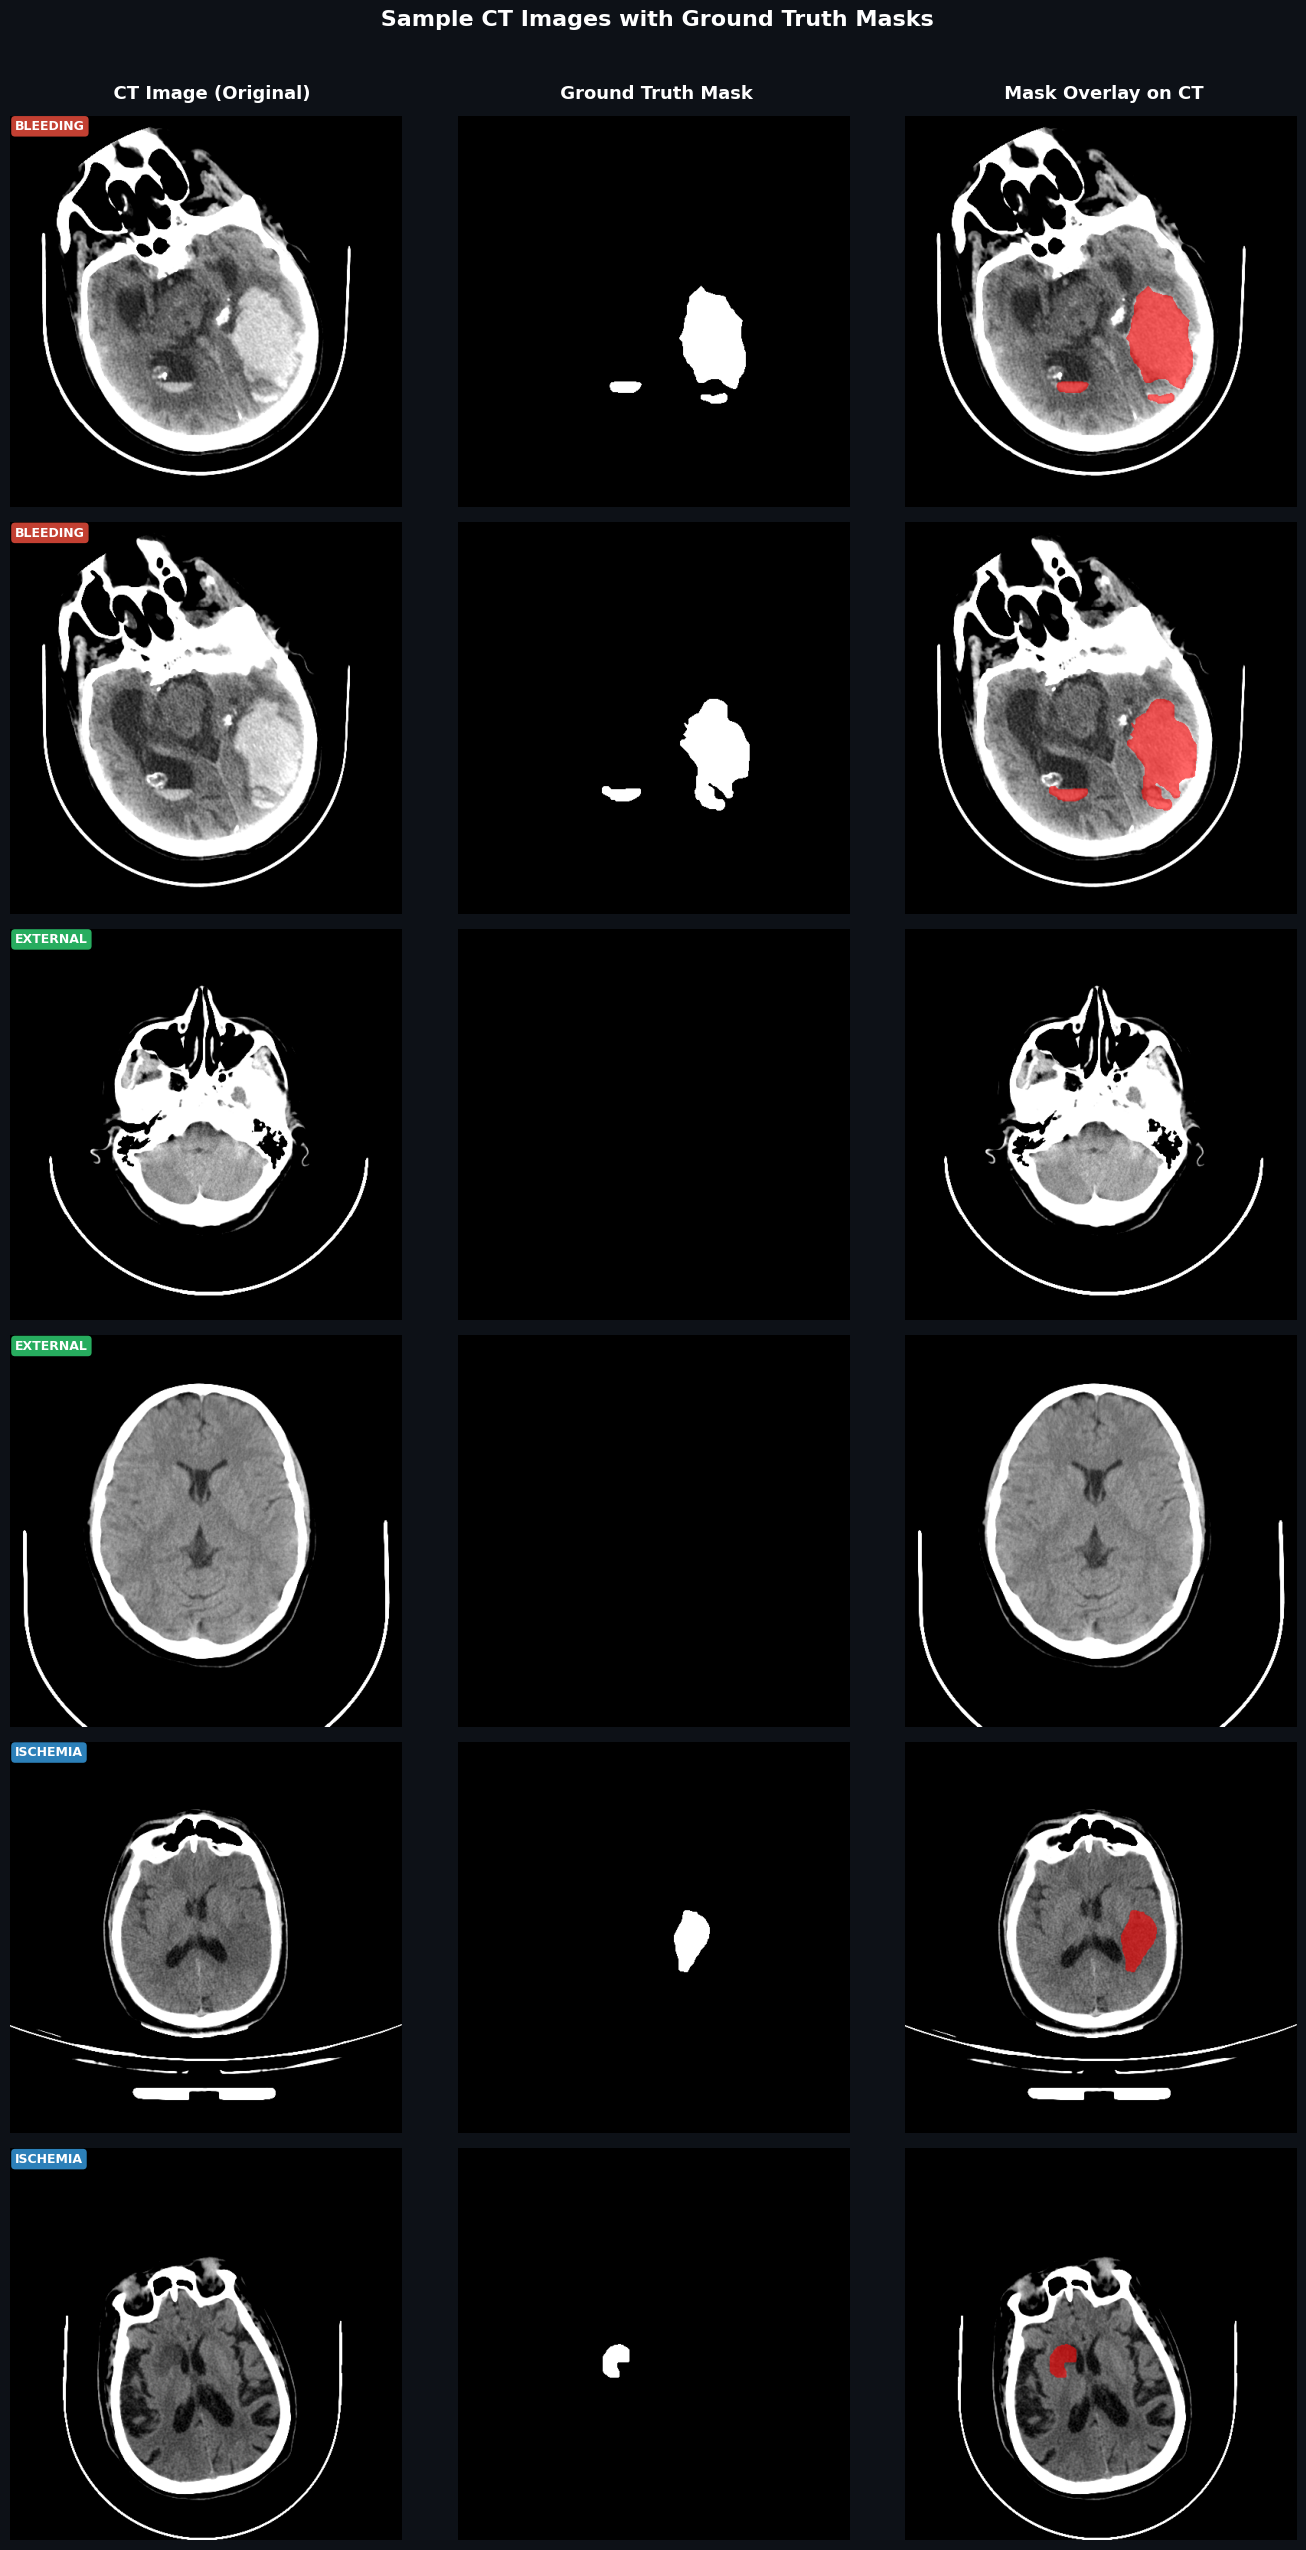

 Sample visualization saved → /kaggle/working/outputs/sample_images.png


In [15]:
#   CELL 5 — Visualize Sample Images & Their Real Masks                    ║
"""
  Before any preprocessing, we visually verify that:
    1. Images load correctly
    2. Overlay-derived masks correctly capture lesion regions
    3. Binary masks align with the original images

    We show 2 samples from each class (bleeding, ischemia, external).
    Columns: Original CT | Ground Truth Mask | Overlay (mask on image)

 Expected output:
    A matplotlib figure saved to /kaggle/working/outputs/sample_images.png
    Shows 6 rows × 3 columns of CT images, masks, and overlays.
"""

def make_mask_from_row(row: pd.Series) -> np.ndarray:
    """Load and convert mask to binary uint8 (0 / 255) based on mask_type."""
    if row["mask_type"] == "overlay":
        ov_bgr  = load_png(row["mask"], grayscale=False)
        orig_bgr = load_png(row["image"], grayscale=False)
        mask    = overlay_to_binary_mask(ov_bgr, orig_bgr=orig_bgr)
    else:
        mask = load_png(row["mask"], grayscale=True)
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask


def visualize_samples(df: pd.DataFrame, n_per_class: int = 2):
    """
    Display n_per_class samples from each label class.
    Columns: CT Image | Ground Truth Mask | Overlay (contour on CT)
    """
    classes = df["label"].unique()
    rows    = len(classes) * n_per_class
    fig, axes = plt.subplots(rows, 3, figsize=(14, rows * 4.2))
    fig.patch.set_facecolor("#0d1117")

    col_titles = ["  CT Image (Original)", " Ground Truth Mask", " Mask Overlay on CT"]
    for col_idx, title in enumerate(col_titles):
        axes[0, col_idx].set_title(title, fontsize=13, color="white",
                                   fontweight="bold", pad=12)

    row_idx = 0
    for label in sorted(classes):
        subset = df[df["label"] == label].sample(
            min(n_per_class, len(df[df["label"] == label])),
            random_state=CFG["SEED"]
        )

        for _, sample_row in subset.iterrows():
            img  = load_png(sample_row["image"], grayscale=False)
            img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mask = make_mask_from_row(sample_row)

            # Create red overlay: draw mask as red channel tint
            overlay_img = img.copy().astype(np.float32)
            red_region  = mask > 127
            overlay_img[red_region, 0] = np.clip(
                overlay_img[red_region, 0] * 0.4 + 255 * 0.6, 0, 255
            )
            overlay_img[red_region, 1] = overlay_img[red_region, 1] * 0.4
            overlay_img[red_region, 2] = overlay_img[red_region, 2] * 0.4
            overlay_img = overlay_img.astype(np.uint8)

            for col_idx, (data, cmap) in enumerate([
                (img,         None),
                (mask,        "gray"),
                (overlay_img, None),
            ]):
                ax = axes[row_idx, col_idx]
                ax.imshow(data, cmap=cmap)
                ax.set_facecolor("#0d1117")

                # Label badge on leftmost column
                if col_idx == 0:
                    badge_color = {"bleeding": "#e74c3c",
                                   "ischemia": "#3498db",
                                   "external": "#2ecc71"}.get(label, "#888")
                    ax.text(6, 18, label.upper(), color="white",
                            fontsize=9, fontweight="bold",
                            bbox=dict(facecolor=badge_color, alpha=0.85,
                                      edgecolor="none", boxstyle="round,pad=0.3"))
                ax.axis("off")
            row_idx += 1

    plt.suptitle(" Sample CT Images with Ground Truth Masks",
                 fontsize=16, color="white", y=1.01, fontweight="bold")
    plt.tight_layout()
    save_path = f"{CFG['WORK_DIR']}/outputs/sample_images.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight",
                facecolor="#0d1117")
    plt.show()
    print(f" Sample visualization saved → {save_path}")


visualize_samples(df_all, n_per_class=2)

##  Train / Validation / Test Split

In [16]:

#  CELL 6 — Train / Validation / Test Split     

"""
 Stratified split ensures each class is proportionally represented
   in all three sets. This is critical for unbalanced medical datasets.

   Split ratio: 75% Train | 15% Val | 10% Test
   stratify=label → each class maintains its proportion across splits.

"""

train_df, test_df = train_test_split(
    df_all,
    test_size    = CFG["TEST_SPLIT"],
    random_state = CFG["SEED"],
    stratify     = df_all["label"],
)
train_df, val_df = train_test_split(
    train_df,
    test_size    = CFG["VAL_SPLIT"] / (1 - CFG["TEST_SPLIT"]),
    random_state = CFG["SEED"],
    stratify     = train_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f" Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}")
print()

# Show class distribution per split
dist_data = {}
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    dist_data[split_name] = split_df["label"].value_counts().to_dict()

dist_df = pd.DataFrame(dist_data).T.fillna(0).astype(int)
print("Class distribution per split:")
print(dist_df.to_string())

 Train : 1816  |  Val : 364  |  Test : 243

Class distribution per split:
       ischemia  bleeding  external
Train       847       819       150
Val         170       164        30
Test        113       110        20


## Augmentation Pipelines

In [17]:
#   CELL 7 — Augmentation Pipelines (Albumentations)                       ║
"""
 Augmentation strategy for medical image segmentation:

  GEOMETRIC (applied to BOTH image AND mask — must match exactly):
    • HorizontalFlip, VerticalFlip, RandomRotate90  → orientation invariance
    • ShiftScaleRotate  → spatial diversity
    • ElasticTransform  → simulates tissue deformation (critical for CT)

  PHOTOMETRIC (applied to IMAGE only — mask is unchanged):
    • RandomBrightnessContrast  → handle scanner intensity variation
    • GaussNoise               → simulate scanner noise

  Validation/Test: resize only — NO augmentation (prevents data leakage).


"""

def build_augmentation_pipeline(training: bool = True) -> A.Compose:
    """Build Albumentations pipeline. Both image AND mask get geometric transforms."""
    if training:
        pipeline = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.05, scale_limit=0.1,
                rotate_limit=15, border_mode=cv2.BORDER_REFLECT, p=0.5
            ),
            A.ElasticTransform(
                alpha=1, sigma=50, alpha_affine=50,
                border_mode=cv2.BORDER_REFLECT, p=0.3
            ),
            A.RandomBrightnessContrast(
                brightness_limit=0.2, contrast_limit=0.2, p=0.5
            ),
            A.GaussNoise(var_limit=(10, 50), p=0.3),
            A.Resize(CFG["IMG_SIZE"], CFG["IMG_SIZE"]),
        ], additional_targets={"mask": "mask"})
    else:
        pipeline = A.Compose([
            A.Resize(CFG["IMG_SIZE"], CFG["IMG_SIZE"]),
        ], additional_targets={"mask": "mask"})

    return pipeline


train_aug = build_augmentation_pipeline(training=True)
val_aug   = build_augmentation_pipeline(training=False)

print(f" Train augmentation  : {len(train_aug.transforms)} transforms")
print(f" Val/Test pipeline   : resize only")

 Train augmentation  : 8 transforms
 Val/Test pipeline   : resize only


##  Data Generator (Keras Sequence)

In [18]:
#   CELL 8 — Data Generator (Keras Sequence)                              

# ── Generator parent class: keras.utils.Sequence (Keras 3 native) ─────────
class BrainSegDataset(keras.utils.PyDataset):
    """
    Keras 3 compatible data generator.
    Inherits from keras.utils.PyDataset (replaces keras.utils.Sequence in Keras 3).
    """

    def __init__(self, dataframe, augment=False, batch_size=8, **kwargs):
        super().__init__(**kwargs)
        self.df         = dataframe.copy().reset_index(drop=True)
        self.aug        = build_augmentation_pipeline(training=augment)
        self.batch_size = batch_size
        self.indices    = np.arange(len(self.df))

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

    def _load_single(self, row):
        img_bgr = load_png(row["image"], grayscale=False)
        img     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        if row["mask_type"] == "overlay":
            ov_bgr = load_png(row["mask"], grayscale=False)
            mask   = overlay_to_binary_mask(ov_bgr, img_bgr)
        else:
            mask = load_png(row["mask"], grayscale=True)
            _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        result = self.aug(image=img, mask=mask)
        img    = result["image"].astype(np.float32) / 255.0
        mask   = (result["mask"] > 127).astype(np.float32)
        mask   = mask[..., np.newaxis]

        return img, mask

    def __getitem__(self, idx):
        batch_indices = self.indices[
            idx * self.batch_size : (idx + 1) * self.batch_size
        ]
        images, masks = [], []
        for i in batch_indices:
            row = self.df.iloc[i]
            try:
                img, mask = self._load_single(row)
                images.append(img)
                masks.append(mask)
            except Exception as e:
                print(f"Warning: Skipping {row['image'].name}: {e}")

        return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)


# Instantiate generators
train_gen = BrainSegDataset(train_df, augment=True,  batch_size=CFG["BATCH_SIZE"])
val_gen   = BrainSegDataset(val_df,   augment=False, batch_size=CFG["BATCH_SIZE"])
test_gen  = BrainSegDataset(test_df,  augment=False, batch_size=CFG["BATCH_SIZE"])

# Sanity check
imgs_s, msks_s = train_gen[0]
print(f"Image shape : {imgs_s.shape}  dtype={imgs_s.dtype}")
print(f"Mask shape  : {msks_s.shape}  dtype={msks_s.dtype}")
print(f"Mask values : {np.unique(msks_s)}")
print(f"Train steps : {len(train_gen)}  |  Val steps : {len(val_gen)}")

Image shape : (8, 256, 256, 3)  dtype=float32
Mask shape  : (8, 256, 256, 1)  dtype=float32
Mask values : [0. 1.]
Train steps : 227  |  Val steps : 46


## Loss Functions & Metrics

In [20]:
#   CELL 9 — Loss Functions & Metrics     

"""
 WHY BCE + Dice Loss?

  Brain lesion pixels are typically <5% of a CT image (severe class imbalance).

  SMOOTH = 1e-6 prevents division-by-zero when mask has no lesion pixels.

 Expected output:
   Loss and metric functions defined.
  Quick test → dice_coeff : 1.0000  |  iou_score : 1.0000
"""

SMOOTH = 1e-6


def dice_coeff(y_true, y_pred):
    """
    Dice Coefficient (F1 score for segmentation).
    Range: 0.0 (no overlap) → 1.0 (perfect overlap).
    Used as the PRIMARY monitoring metric during training.
    """
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + SMOOTH) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + SMOOTH
    )


def dice_loss(y_true, y_pred):
    """1 - Dice Coefficient (minimised during training)."""
    return 1.0 - dice_coeff(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    """
    Combined loss: Binary Cross-Entropy + Dice Loss.
    BCE handles pixel probability; Dice handles region overlap.
    Together they provide stable gradients AND imbalance robustness.
    """
    bce  = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice


def iou_score(y_true, y_pred, threshold: float = 0.5):
    """
    Intersection over Union (Jaccard Index).
    Thresholds predictions at 0.5 before computing overlap.
    Range: 0.0 → 1.0 (higher is better).
    """
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    y_true_f   = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_bin)
    union        = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_bin) - intersection
    return (intersection + SMOOTH) / (union + SMOOTH)


# Quick unit test on identical arrays
_t = tf.ones([1, 64, 64, 1])
print(f" Loss and metric functions defined.")
print(f"   Quick test → dice_coeff : {dice_coeff(_t, _t).numpy():.4f}"
      f"  |  iou_score : {iou_score(_t, _t).numpy():.4f}")

 Loss and metric functions defined.
   Quick test → dice_coeff : 1.0000  |  iou_score : 1.0000


##  Build Attention U-Net (ResNet34 Encoder)

In [21]:
#   CELL 10 — Build Attention U-Net (Pure Keras, no segmentation_models)  
"""
Architecture: Custom Attention U-Net (pure tf_keras — no external libraries)

WHY dropped segmentation_models?
  segmentation_models uses Keras 3 internally, but our code uses tf_keras
  (Keras 2). Mixing both causes:
    ValueError: Could not interpret optimizer identifier
  Solution: use a fully custom Attention U-Net built entirely with tf_keras.

Architecture summary:
  Input (256x256x3)
    -> Encoder: 4 blocks (64 -> 128 -> 256 -> 512 channels)
    -> Bottleneck: 1024 channels
    -> Decoder: 4 blocks with Attention Gates on every skip connection
    -> Output: Conv2D(1, sigmoid) -> binary mask (256x256x1)

WHY Attention Gates?
  Standard U-Net skip connections pass ALL encoder features to the decoder,
  including irrelevant background. Attention Gates learn to suppress
  background activations and focus on lesion regions only.
  Critical for small lesions that occupy < 5% of the CT slice.


"""

# ── Building blocks 

def conv_block(x, filters, kernel_size=3, use_batchnorm=True):
    """Two Conv2D + BatchNorm + ReLU layers. Core U-Net building block."""
    for _ in range(2):
        x = layers.Conv2D(filters, kernel_size, padding="same",
                          kernel_initializer="he_normal")(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
    return x


def encoder_block(x, filters, dropout_rate=0.2):
    """Conv block followed by MaxPool. Returns (skip connection, pooled output)."""
    skip = conv_block(x, filters)
    pool = layers.MaxPooling2D(pool_size=2)(skip)
    pool = layers.Dropout(dropout_rate)(pool)
    return skip, pool


def attention_gate(g, s, inter_filters):
    """
    Attention Gate — learns to focus on relevant spatial regions.

    g : gating signal from decoder (coarser resolution, more semantic)
    s : skip connection from encoder (finer resolution, more spatial)

    Mechanism:
      1. Project g and s to inter_filters channels
      2. Add -> ReLU -> 1x1 Conv -> Sigmoid  (produces attention map in [0,1])
      3. Multiply skip connection by attention map
         -> suppresses irrelevant background, highlights lesion regions
    """
    Wg  = layers.Conv2D(inter_filters, kernel_size=1, padding="same")(g)
    Ws  = layers.Conv2D(inter_filters, kernel_size=1, padding="same")(s)
    psi = layers.Activation("relu")(layers.Add()([Wg, Ws]))
    psi = layers.Conv2D(1, kernel_size=1, padding="same")(psi)
    psi = layers.Activation("sigmoid")(psi)   # attention map alpha in [0,1]
    return layers.Multiply()([s, psi])         # weighted skip connection


def decoder_block(x, skip, filters, dropout_rate=0.2):
    """Upsample -> AttentionGate(skip) -> Concatenate -> ConvBlock."""
    x    = layers.UpSampling2D(size=2, interpolation="bilinear")(x)
    skip = attention_gate(g=x, s=skip, inter_filters=filters // 2)
    x    = layers.Concatenate()([x, skip])
    x    = layers.Dropout(dropout_rate)(x)
    x    = conv_block(x, filters)
    return x


def build_attention_unet(img_size=256, channels=3):
    """Build full Attention U-Net. Returns a tf_keras Model."""
    inputs = keras.Input(shape=(img_size, img_size, channels), name="ct_input")

    # Encoder
    s1, p1 = encoder_block(inputs,  64,  dropout_rate=0.1)
    s2, p2 = encoder_block(p1,     128,  dropout_rate=0.1)
    s3, p3 = encoder_block(p2,     256,  dropout_rate=0.2)
    s4, p4 = encoder_block(p3,     512,  dropout_rate=0.2)

    # Bottleneck
    b = conv_block(p4, 1024)
    b = layers.Dropout(0.3)(b)

    # Decoder with Attention Gates
    d4 = decoder_block(b,  s4, 512, dropout_rate=0.2)
    d3 = decoder_block(d4, s3, 256, dropout_rate=0.2)
    d2 = decoder_block(d3, s2, 128, dropout_rate=0.1)
    d1 = decoder_block(d2, s1,  64, dropout_rate=0.1)

    # Output layer — sigmoid for binary segmentation
    outputs = layers.Conv2D(1, kernel_size=1,
                            activation="sigmoid",
                            name="seg_output")(d1)

    return keras.Model(inputs=inputs, outputs=outputs, name="AttentionUNet")


# ── Build and compile 
model = build_attention_unet(
    img_size = CFG["IMG_SIZE"],
    channels = CFG["CHANNELS"],
)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=CFG["LR"]),
    loss      = bce_dice_loss,
    metrics   = [dice_coeff, iou_score],
)

# Print summary
total_params     = model.count_params()
trainable_params = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f"Model     : {model.name}")
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
model.summary(line_length=100)

Model     : AttentionUNet
Total params     : 31,926,181
Trainable params : 31,914,405


Model: "AttentionUNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ct_input (InputLayer)       │ (None, 256, 256, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d (Conv2D)             │ (None, 256, 256, 64)    │          1,792 │ ct_input[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization         │ (None, 256, 256, 64)    │            256 │ conv2d[0][0]            │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation (Activation)     │ (None, 256, 256, 64)    │              0 │ batch_normalization[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_1 (Conv2D)           │ (None, 256, 256, 64)    │         36,928 │ activation[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_1       │ (None, 256, 256, 64)    │            256 │ conv2d_1[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation_1 (Activation)   │ (None, 256, 256, 64)    │              0 │ batch_normalization_1[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling2d               │ (None, 128, 128, 64)    │              0 │ activation_1[0][0]      │
│ (MaxPooling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout (Dropout)           │ (None, 128, 128, 64)    │              0 │ max_pooling2d[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_2 (Conv2D)           │ (None, 128, 128, 128)   │         73,856 │ dropout[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_2       │ (None, 128, 128, 128)   │            512 │ conv2d_2[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation_2 (Activation)   │ (None, 128, 128, 128)   │              0 │ batch_normalization_2[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_3 (Conv2D)           │ (None, 128, 128, 128)   │        147,584 │ activation_2[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_3       │ (None, 128, 128, 128)   │            512 │ conv2d_3[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation_3 (Activation)   │ (None, 128, 128, 128)   │              0 │ batch_normalization_3[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling2d_1             │ (None, 64, 64, 128)     │              0 │ activation_3[0][0]      │
│ (MaxPooling2D)              │                         │    

 Total params: 31,926,181 (121.79 MB)

 Trainable params: 31,914,405 (121.74 MB)

 Non-trainable params: 11,776 (46.00 KB)

## Checkpoint & Resume Logic

In [34]:
import os

# Delete last checkpoint
if os.path.exists(CFG["LAST_CKPT"]):
    os.remove(CFG["LAST_CKPT"])
    print("Deleted last checkpoint.")

# Delete epoch log
if os.path.exists(CFG["EPOCH_LOG"]):
    os.remove(CFG["EPOCH_LOG"])
    print("Deleted epoch log.")

Deleted last checkpoint.
Deleted epoch log.


In [36]:
# ================================
# IMPORTS
# ================================
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow import keras   #  USE tensorflow.keras

# ================================
# CONFIG
# ================================
CFG = {
    "CKPT_DIR"   : "/kaggle/working/checkpoints",
    "BEST_CKPT"  : "/kaggle/working/checkpoints/best_model.keras",
    "LAST_CKPT"  : "/kaggle/working/checkpoints/last_epoch_model.keras",
    "EPOCH_LOG"  : "/kaggle/working/checkpoints/epoch_log.json",
    "BATCH_SIZE" : 8,
    "EPOCHS"     : 50
}

os.makedirs(CFG["CKPT_DIR"], exist_ok=True)

# ================================
# CUSTOM CALLBACK FOR LAST EPOCH SAVE
# ================================
class SaveLastEpoch(keras.callbacks.Callback):
    def __init__(self, save_path, log_path):
        super().__init__()
        self.save_path = save_path
        self.log_path  = log_path

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # Save full model
        self.model.save(self.save_path, overwrite=True)

        # Save log
        log_data = {
            "last_epoch"     : int(epoch + 1),
            "val_dice_coeff" : float(logs.get("val_dice_coeff", 0.0)),
            "val_iou_score"  : float(logs.get("val_iou_score", 0.0)),
            "val_loss"       : float(logs.get("val_loss", 0.0)),
            "timestamp"      : datetime.now().isoformat(),
        }
        with open(self.log_path, "w") as f:
            json.dump(log_data, f, indent=4)

# ================================
# RESUME LOGIC
# ================================
initial_epoch = 0

if os.path.exists(CFG["LAST_CKPT"]):
    print(f"Resuming from: {CFG['LAST_CKPT']}")
    model = keras.models.load_model(
        CFG["LAST_CKPT"],
        custom_objects={
            "bce_dice_loss": bce_dice_loss,
            "dice_coeff"   : dice_coeff,
            "iou_score"    : iou_score,
        },
        compile=True
    )
    if os.path.exists(CFG["EPOCH_LOG"]):
        with open(CFG["EPOCH_LOG"], "r") as f:
            log_data = json.load(f)
        initial_epoch = int(log_data.get("last_epoch", 0))
        print(f" Last completed epoch : {initial_epoch}")
        print(f" Best val dice so far : {float(log_data.get('val_dice_coeff', 0)):.4f}")
        print(f" Last val IoU         : {float(log_data.get('val_iou_score', 0)):.4f}")
else:
    print(" No checkpoint found — starting fresh training.")

print(f" initial_epoch = {initial_epoch}")

# ================================
# CALLBACKS
# ================================
callbacks = [
    keras.callbacks.ModelCheckpoint(
        CFG["BEST_CKPT"],
        monitor="val_dice_coeff",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    SaveLastEpoch(
        save_path=CFG["LAST_CKPT"],
        log_path=CFG["EPOCH_LOG"]
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_dice_coeff",
        patience=10,
        mode="max",
        restore_best_weights=True
    )
]

# ================================
# TRAINING WITH KERAS SEQUENCE GENERATOR
# ================================
history = model.fit(
    train_gen,                 #  BrainSegDataset generator
    validation_data=val_gen,   # generator
    epochs=CFG["EPOCHS"],
    initial_epoch=initial_epoch,
    callbacks=callbacks
)

Resuming from: /kaggle/working/checkpoints/last_epoch_model.keras
 Last completed epoch : 26
 Best val dice so far : 0.6689
 Last val IoU         : 0.5339
 initial_epoch = 26
Epoch 27/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - dice_coeff: 0.7050 - iou_score: 0.5707 - loss: 0.3315
Epoch 27: val_dice_coeff improved from -inf to 0.68093, saving model to /kaggle/working/checkpoints/best_model.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 126s 413ms/step - dice_coeff: 0.7050 - iou_score: 0.5707 - loss: 0.3315 - val_dice_coeff: 0.6809 - val_iou_score: 0.5422 - val_loss: 0.3541
Epoch 28/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - dice_coeff: 0.6994 - iou_score: 0.5615 - loss: 0.3387
Epoch 28: val_dice_coeff did not improve from 0.68093
227/227 ━━━━━━━━━━━━━━━━━━━━ 83s 363ms/step - dice_coeff: 0.6994 - iou_score: 0.5615 - loss: 0.3387 - val_dice_coeff: 0.6054 - val_iou_score: 0.4630 - val_loss: 0.4376
Epoch 29/50
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - dice_coeff: 0.6678 - iou_score: 0.5276

In [41]:
# Print summary of training
print("\n===== Training Report =====\n")

print(f"Best validation Dice   : {max(history.history.get('val_dice_coeff', [0])):.4f}")
print(f"Best validation IoU    : {max(history.history.get('val_iou_score', [0])):.4f}")
print(f"Minimum validation loss: {min(history.history.get('val_loss', [np.inf])):.4f}\n")

# Optionally show last 5 epochs metrics
report_df = pd.DataFrame(history.history)
print("Last 5 epochs metrics:")
display(report_df.tail())


===== Training Report =====

Best validation Dice   : 0.7050
Best validation IoU    : 0.5659
Minimum validation loss: 0.3327

Last 5 epochs metrics:


,dice_coeff,iou_score,loss,val_dice_coeff,val_iou_score,val_loss
19,0.704052,0.567037,0.332864,0.683920,0.546106,0.350695
20,0.697319,0.561105,0.339535,0.705032,0.565883,0.334952
21,0.713721,0.579833,0.320465,0.650860,0.511583,0.391568
22,0.714518,0.581280,0.319909,0.702538,0.562161,0.337613
23,0.706617,0.569911,0.329741,0.690340,0.550207,0.350705


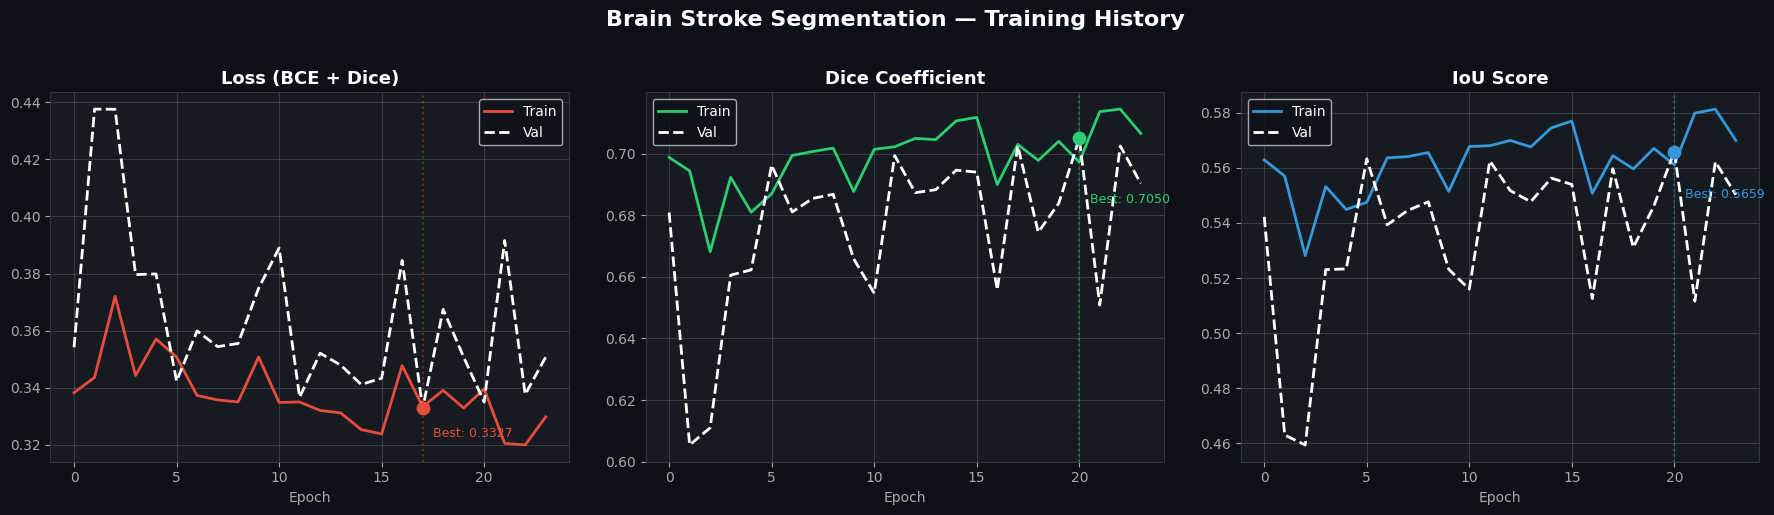

In [43]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    metrics = [
        ("loss",       "val_loss",       "Loss (BCE + Dice)", "#e74c3c"),
        ("dice_coeff", "val_dice_coeff", "Dice Coefficient",  "#2ecc71"),
        ("iou_score",  "val_iou_score",  "IoU Score",         "#3498db"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor("#0d1117")

    for ax, (train_key, val_key, title, color) in zip(axes, metrics):
        ax.set_facecolor("#161b22")
        ax.plot(history.history[train_key],  color=color,    linewidth=2, label="Train")
        ax.plot(history.history[val_key],    color="white",  linewidth=2, label="Val", linestyle="--")

        # Mark best validation epoch
        if "dice" in val_key or "iou" in val_key:
            best_idx = max(range(len(history.history[val_key])),
                           key=lambda i: history.history[val_key][i])
        else:
            best_idx = min(range(len(history.history[val_key])),
                           key=lambda i: history.history[val_key][i])
        best_val = history.history[val_key][best_idx]
        ax.axvline(best_idx, color=color, alpha=0.4, linestyle=":")
        ax.scatter([best_idx], [best_val], color=color, s=80, zorder=5)
        ax.annotate(f"Best: {best_val:.4f}",
                    xy=(best_idx, best_val),
                    xytext=(best_idx + 0.5, best_val * 0.97),
                    color=color, fontsize=9)

        ax.set_title(title,     color="white", fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch",  color="#aaaaaa", fontsize=10)
        ax.tick_params(colors="#aaaaaa")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363d")
        ax.legend(facecolor="#0d1117", labelcolor="white", fontsize=10)
        ax.grid(True, alpha=0.15, color="#ffffff")

    plt.suptitle("Brain Stroke Segmentation — Training History",
                 fontsize=16, color="white", y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_training_curves(history)

In [44]:
os.makedirs(f"{CFG.get('WORK_DIR', '/kaggle/working')}/outputs", exist_ok=True)
hist_df = pd.DataFrame(history.history)
hist_csv_path = f"{CFG.get('WORK_DIR', '/kaggle/working')}/outputs/training_log.csv"
hist_df.to_csv(hist_csv_path, index=False)
print(f"Full epoch-wise history saved → {hist_csv_path}")

Full epoch-wise history saved → /kaggle/working/outputs/training_log.csv


## Evaluation on Test Set

In [45]:
#   CELL 15 — Evaluation on Test Set   

"""
 Load BEST model (highest val Dice) for final evaluation.
   Always evaluate on the best checkpoint, not the last epoch.


"""

# Load best checkpoint for evaluation
print(" Loading best model for evaluation …")
best_model = keras.models.load_model(  # keras = tf_keras
    CFG["BEST_CKPT"],
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coeff"   : dice_coeff,
        "iou_score"    : iou_score,
    },
)

print(f"\n Evaluating best model on hold-out test set ({len(test_df)} samples) …")
test_results = best_model.evaluate(test_gen, verbose=1)

metric_names = ["Loss (BCE+Dice)", "Dice Coefficient", "IoU Score"]
print("\n" + "═" * 46)
print("  Final Test Results (Best Model)")
print("═" * 46)
for name, val in zip(metric_names, test_results):
    print(f"  {name:22s}:  {val:.4f}")
print("═" * 46)

 Loading best model for evaluation …

 Evaluating best model on hold-out test set (243 samples) …
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 355ms/step - dice_coeff: 0.7469 - iou_score: 0.6170 - loss: 0.2850

══════════════════════════════════════════════
  Final Test Results (Best Model)
══════════════════════════════════════════════
  Loss (BCE+Dice)       :  0.2741
  Dice Coefficient      :  0.7571
  IoU Score             :  0.6323
══════════════════════════════════════════════


##  Visualize Predictions

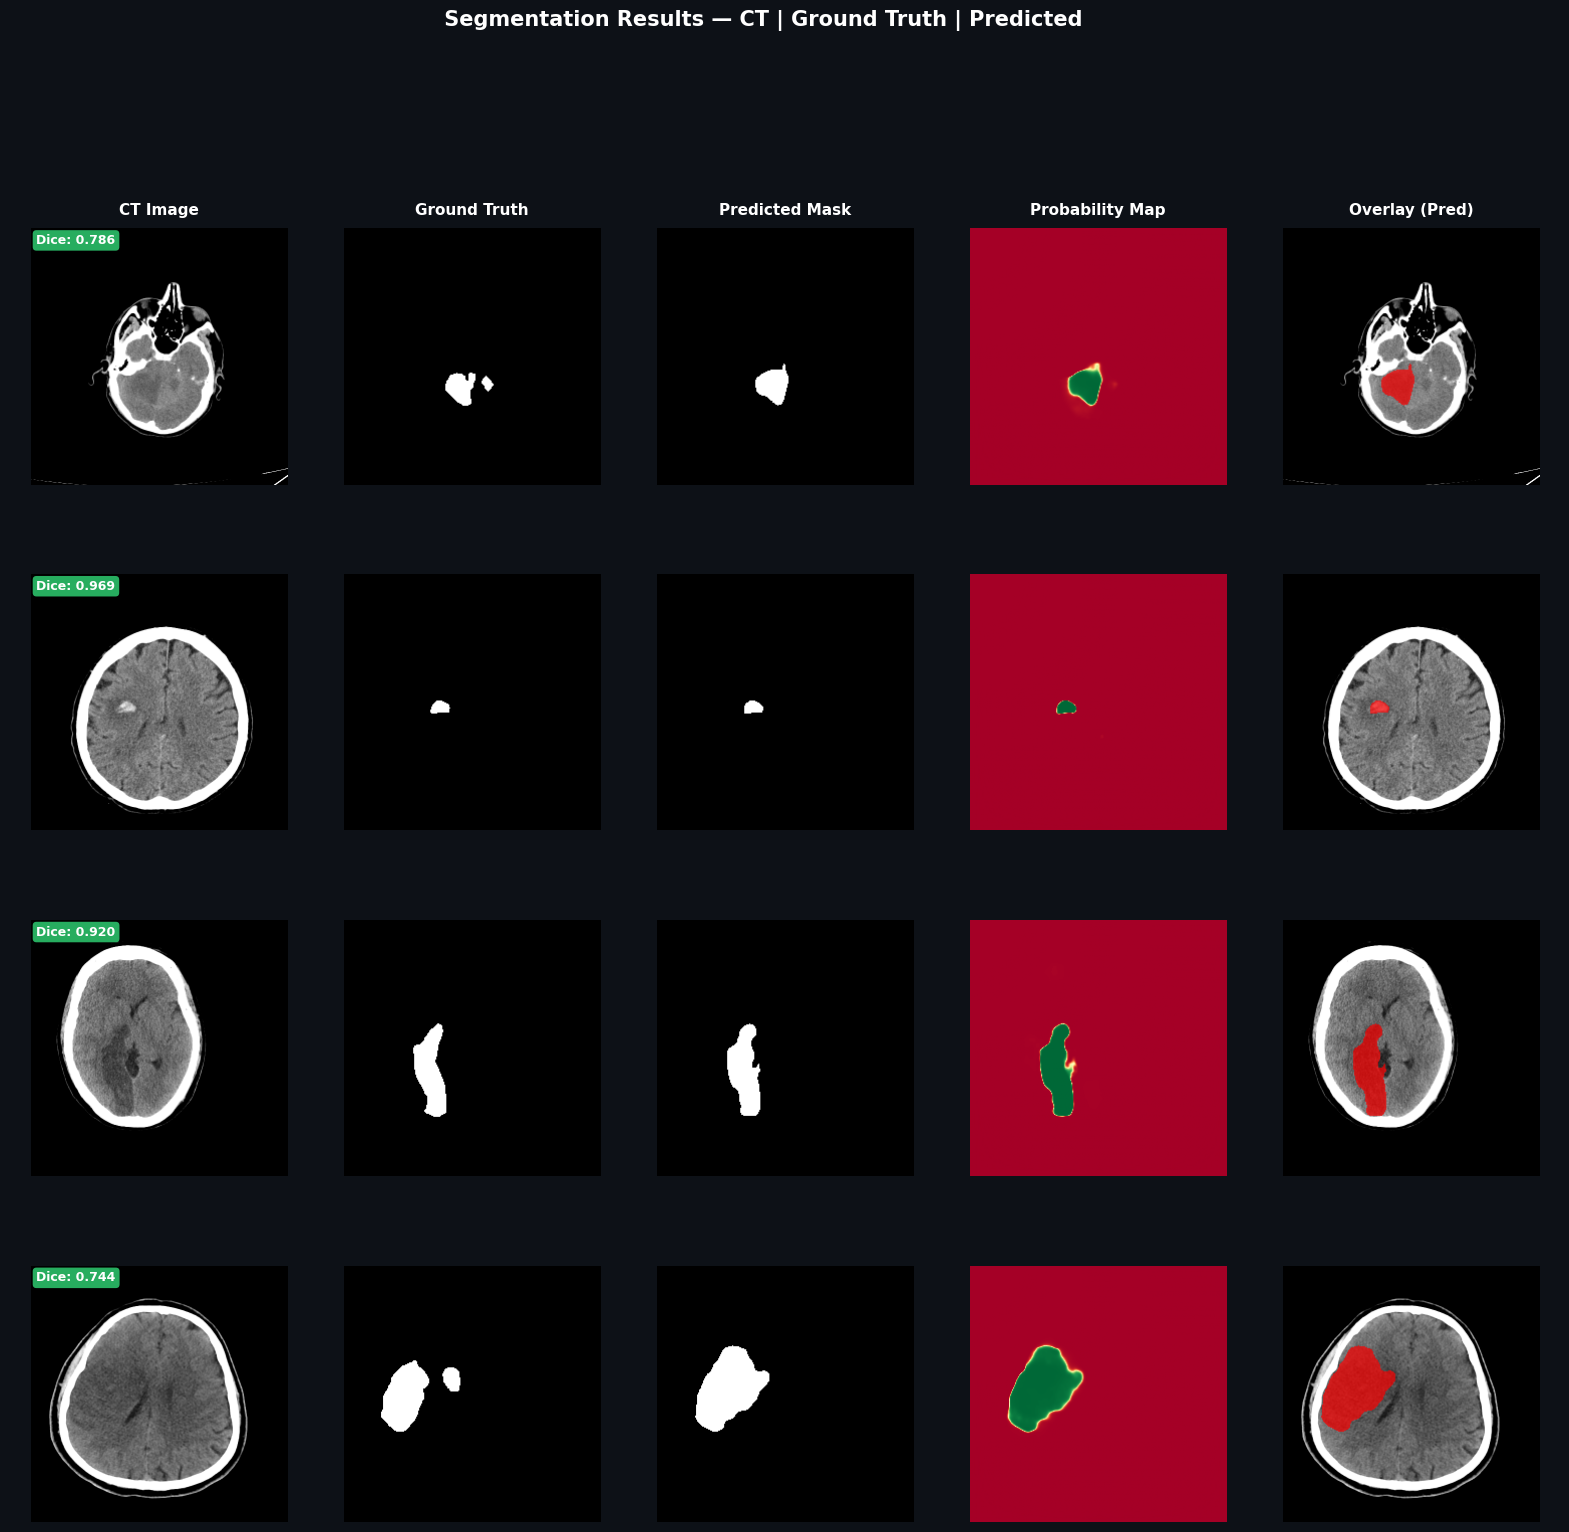

 Predictions visualization saved → /kaggle/working/outputs/predictions.png


In [49]:
#   CELL 16 — Visualize Predictions                                        

"""
  For each test sample (n=6), show:
   Col 1: Original CT image
   Col 2: Ground truth mask (real, from dataset)
   Col 3: Predicted mask (threshold=0.5)
   Col 4: Probability heatmap (raw sigmoid output)
   Col 5: Prediction overlaid on CT (red = predicted lesion)

   Also displays per-sample Dice score for each row.

"""

def visualize_predictions(generator, model, n_samples: int = 6,
                           threshold: float = 0.5):
    """Show CT | GT mask | Pred mask | Heatmap | Overlay for n_samples."""

    imgs, masks = generator[0]
    preds       = model.predict(imgs, verbose=0)
    n           = min(n_samples, len(imgs))

    fig = plt.figure(figsize=(20, n * 4.2))
    fig.patch.set_facecolor("#0d1117")
    gs  = gridspec.GridSpec(n, 5, figure=fig, hspace=0.35, wspace=0.05)

    col_titles = ["CT Image", "Ground Truth", "Predicted Mask",
                  "Probability Map", "Overlay (Pred)"]
    for j, title in enumerate(col_titles):
        ax = fig.add_subplot(gs[0, j])
        ax.set_title(title, color="white", fontsize=11,
                     fontweight="bold", pad=10)
        ax.axis("off")

    for i in range(n):
        img      = imgs[i]
        gt       = masks[i, ..., 0]
        prob_map = preds[i, ..., 0]
        pred_bin = (prob_map > threshold).astype(np.float32)

        # Compute per-sample Dice
        intersection = np.sum(gt * pred_bin)
        sample_dice  = (2 * intersection + SMOOTH) / (
            np.sum(gt) + np.sum(pred_bin) + SMOOTH
        )

        # Build red overlay
        overlay = img.copy().astype(np.float32)
        lesion  = pred_bin > 0.5
        overlay[lesion, 0] = np.clip(overlay[lesion, 0] * 0.3 + 0.7, 0, 1)
        overlay[lesion, 1] = overlay[lesion, 1] * 0.3
        overlay[lesion, 2] = overlay[lesion, 2] * 0.3

        data_list = [
            (img,      None,       "none"),
            (gt,       "gray",     "none"),
            (pred_bin, "gray",     "none"),
            (prob_map, "RdYlGn",   "none"),
            (overlay,  None,       "none"),
        ]

        for j, (data, cmap, _) in enumerate(data_list):
            ax = fig.add_subplot(gs[i, j])
            ax.set_facecolor("#0d1117")
            ax.imshow(data, cmap=cmap, vmin=0, vmax=1)

            # Dice badge on first column
            if j == 0:
                color = "#2ecc71" if sample_dice > 0.7 else (
                        "#f39c12" if sample_dice > 0.5 else "#e74c3c")
                ax.text(5, 15, f"Dice: {sample_dice:.3f}",
                        color="white", fontsize=9, fontweight="bold",
                        bbox=dict(facecolor=color, alpha=0.85,
                                  edgecolor="none", boxstyle="round,pad=0.3"))
            ax.axis("off")

    plt.suptitle(" Segmentation Results — CT | Ground Truth | Predicted",
                 fontsize=15, color="white", y=1.01, fontweight="bold")

    save_path = f"{CFG['WORK_DIR']}/outputs/predictions.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print(f" Predictions visualization saved → {save_path}")


visualize_predictions(test_gen, best_model, n_samples=4)

## Per-Sample Metrics & Score Distribution

Computing per-sample metrics on 243 test images …

══════════════════════════════════════════════════
  Per-Sample Test Metrics  (243 images)
══════════════════════════════════════════════════
  Mean Dice  :  0.6501 ± 0.3770
  Mean IoU   :  0.5808 ± 0.3591
  Dice > 0.7 :  163 / 243  (67.1%)
  Dice > 0.5 :  175 / 243  (72.0%)
══════════════════════════════════════════════════


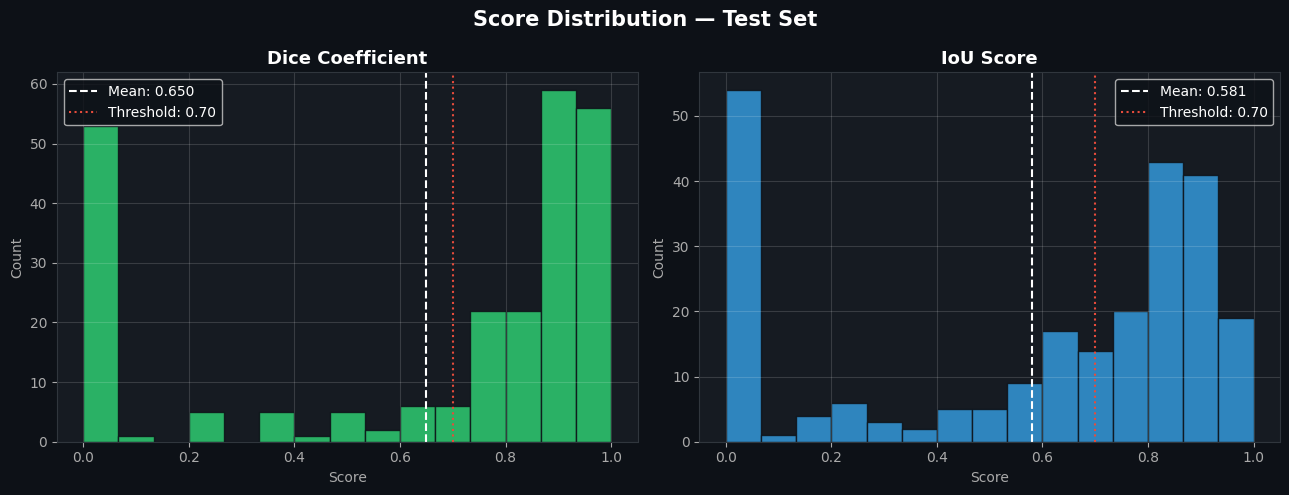

 Score distributions saved → /kaggle/working/outputs/score_distributions.png


In [50]:
#Per-Sample Metrics & Score Distribution      

"""
 Compute Dice + IoU for every single test image individually.
   This reveals:
   • Overall mean ± std performance
   • How many samples score above 0.7 (clinical threshold)
   • Distribution of scores (histogram)
   • Worst-performing samples for error analysis


"""

def compute_per_sample_metrics(generator, model, threshold: float = 0.5):
    """Compute per-image Dice and IoU across all batches in generator."""
    dice_scores, iou_scores = [], []

    print(f"Computing per-sample metrics on {len(generator.df)} test images …")

    for batch_idx in range(len(generator)):
        imgs, masks = generator[batch_idx]
        preds = model.predict(imgs, verbose=0)
        preds_bin = (preds > threshold).astype(np.float32)

        for j in range(len(imgs)):
            gt   = masks[j].flatten()
            pred = preds_bin[j].flatten()

            intersection = np.sum(gt * pred)
            union        = np.sum(gt) + np.sum(pred) - intersection

            dice = (2 * intersection + SMOOTH) / (np.sum(gt) + np.sum(pred) + SMOOTH)
            iou  = (intersection + SMOOTH) / (union + SMOOTH)

            dice_scores.append(float(dice))
            iou_scores.append(float(iou))

    n = len(dice_scores)
    above_07 = sum(d > 0.7 for d in dice_scores)
    above_05 = sum(d > 0.5 for d in dice_scores)

    print(f"\n{'═'*50}")
    print(f"  Per-Sample Test Metrics  ({n} images)")
    print(f"{'═'*50}")
    print(f"  Mean Dice  :  {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
    print(f"  Mean IoU   :  {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
    print(f"  Dice > 0.7 :  {above_07} / {n}  ({100*above_07/n:.1f}%)")
    print(f"  Dice > 0.5 :  {above_05} / {n}  ({100*above_05/n:.1f}%)")
    print(f"{'═'*50}")

    return dice_scores, iou_scores


dice_scores, iou_scores = compute_per_sample_metrics(test_gen, best_model)

# ── Score distribution histograms 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#0d1117")

for ax, scores, color, metric in [
    (ax1, dice_scores, "#2ecc71", "Dice Coefficient"),
    (ax2, iou_scores,  "#3498db", "IoU Score"),
]:
    ax.set_facecolor("#161b22")
    ax.hist(scores, bins=15, color=color, edgecolor="#0d1117", alpha=0.85)
    ax.axvline(np.mean(scores), color="white", linestyle="--", linewidth=1.5,
               label=f"Mean: {np.mean(scores):.3f}")
    ax.axvline(0.7, color="#e74c3c", linestyle=":", linewidth=1.5,
               label="Threshold: 0.70")
    ax.set_title(metric,      color="white", fontsize=13, fontweight="bold")
    ax.set_xlabel("Score",    color="#aaaaaa")
    ax.set_ylabel("Count",    color="#aaaaaa")
    ax.tick_params(colors="#aaaaaa")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.legend(facecolor="#0d1117", labelcolor="white")
    ax.grid(True, alpha=0.15, color="#ffffff")

plt.suptitle("Score Distribution — Test Set",
             color="white", fontsize=15, fontweight="bold")
plt.tight_layout()
save_path = f"{CFG['WORK_DIR']}/outputs/score_distributions.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f" Score distributions saved → {save_path}")

##  Final Summary

In [51]:
# Final Summary             

"""
 Pipeline complete. All outputs saved to /kaggle/working/outputs/


"""

final_dice = np.mean(dice_scores)
final_iou  = np.mean(iou_scores)

print()
print("═" * 54)
print("   Brain Stroke Segmentation — Pipeline Complete")
print("═" * 54)
print("  Saved files:")
print(f"    checkpoints/best_model.keras        — best val dice model")
print(f"    checkpoints/last_epoch_model.keras  — resume checkpoint")
print(f"    checkpoints/epoch_log.json          — last epoch metadata")
print(f"    outputs/sample_images.png           — raw data preview")
print(f"    outputs/training_curves.png         — loss/dice/iou plots")
print(f"    outputs/training_log.csv            — per-epoch metric log")
print(f"    outputs/predictions.png             — visual results")
print(f"    outputs/score_distributions.png     — score histograms")
print("═" * 54)
print(f"  Final Test Dice :  {final_dice:.4f}")
print(f"  Final Test IoU  :  {final_iou:.4f}")
print("═" * 54)


══════════════════════════════════════════════════════
   Brain Stroke Segmentation — Pipeline Complete
══════════════════════════════════════════════════════
  Saved files:
    checkpoints/best_model.keras        — best val dice model
    checkpoints/last_epoch_model.keras  — resume checkpoint
    checkpoints/epoch_log.json          — last epoch metadata
    outputs/sample_images.png           — raw data preview
    outputs/training_curves.png         — loss/dice/iou plots
    outputs/training_log.csv            — per-epoch metric log
    outputs/predictions.png             — visual results
    outputs/score_distributions.png     — score histograms
══════════════════════════════════════════════════════
  Final Test Dice :  0.6501
  Final Test IoU  :  0.5808
══════════════════════════════════════════════════════
